# Modelo predictivo v3: carga por tolva, masa de escoria por trazador CaO y prescriptor en kg de Sn

Continuación de `analisis_lingo_smelter.ipynb` (Pasos 0-48) y `modelo_v2_causalidad_y_prescripcion.ipynb`
(Pasos 49-55). Sesión 2026-09-13 (noche), motivada por el pedido de **volver a explorar y mejorar el modelo
predictivo para el mejor prescriptor operacional**, incorporando los datos del Excel que las rondas anteriores
no usaban: alimentación y Sn fino **por tolva** (1 concentrado, 3 reciclo Sn/Fe, 4 mineral de Fe WF, 5 dross de
Fe, 7 pellets/humos), la **duración planificada** del escalón, el estado del **refractario** y la corrección de la
cal (`CaO total` del Excel = tolva 6 + tolva 3).

Todo el código importa y ejecuta `modelo_predictivo_v3.py` (fuente de verdad de la ronda), `feature_engineering.py`
(bloque v3) y `dataset_lingo_smelter.py` (loader extendido). Los experimentos pesados viven en `experimentos/06-12_*.py`
y sus CSV; aquí se cargan sus salidas (poner `RECALCULAR = True` para reproducirlos desde cero). Resumen escrito
completo: `hallazgos.md` sección 14. Numeración: **Paso 56 en adelante**.

In [1]:
import warnings, re
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

import dataset_lingo_smelter as dls
import feature_engineering as fe
import modelo_prescriptivo as mp
import modelo_predictivo_v3 as mp3

pd.set_option("display.width", 180); pd.set_option("display.max_columns", 60)
EXP = Path("experimentos")
RECALCULAR = False   # True: re-ejecuta los experimentos pesados en vez de leer sus CSV

df = mp3.construir_dataset_modelo_v3("Datos Lingo smelter fase II.xlsx")
df_base = mp.dataset_base_modelo(df)
batches_dev, batches_lockbox = mp.split_dev_lockbox(df)
F, R = df["fase_proceso"] == "Fusión", df["fase_proceso"] == "Reducción"
print(f"df {df.shape} | columnas seguras para prescripcion: {len(fe.filtrar_features_seguras(list(df.columns)))} | dev={len(batches_dev)} lockbox={len(batches_lockbox)}")

limpiar_dataset: 2 valor(es) marcados como NaN en 2 columna(s) (detalle en el reporte devuelto).


df (3982, 222) | columnas seguras para prescripcion: 137 | dev=299 lockbox=63


## Paso 56: verificaciones sobre el Excel que fundamentan la ronda

Antes de crear features se verificó, fila por fila, qué representan las columnas nuevas (detalle en
`diccionario_datos.json` → `_meta.actualizacion_2026_09_13_noche`).

In [2]:
raw = pd.read_excel("Datos Lingo smelter fase II.xlsx", sheet_name="Datos").sort_values(["Batch", "Fecha inicio real"])
tmh_sum = raw[["tmh tolva 1 concentrado", "tmh tolva 3 alimentacin (Kg)", "tmh tolva 4 Hierro WF (Kg)", "tmh tolva 5 Dross Fierro", "tmh tolva 7 alimentador"]].sum(axis=1)
tmf_sum = raw[["tmf Sn tolva 1 concentrado", "tmf Sn tolva 3 alimentacion (Kg)", "tmf Sn tolva 4 Hierro WF (Kg)", "tmf Sn tolva 5 Dross Fierro", "tmf Sn tolva 7 alimentador"]].sum(axis=1)
cao_t6_t3 = raw["Kgmh tolva 6 Oxido de Calcio"].fillna(0) + raw["tmh tolva 3 alimentacin (Kg)"].fillna(0)
ley_t1 = 100 * raw["tmf Sn tolva 1 concentrado"] / raw["tmh tolva 1 concentrado"].where(raw["tmh tolva 1 concentrado"] > 50)
dur_real = (raw["Fecha final real"] - raw["Fecha inicio real"]).dt.total_seconds() / 60
dur_plan = dls._duracion_plan_a_minutos(raw["duracion plan"])
print("TMH total == suma tolvas 1,3,4,5,7 :", int((raw["TMH tolva: 3+4+5+7+1 (Kg)"] - tmh_sum).abs().lt(1e-3).sum()), "/", len(raw))
print("TMF Sn total == suma tmf tolvas   :", int((raw["TMF Sn total F+ R (Kg)"] - tmf_sum).abs().lt(1e-3).sum()), "/", len(raw))
print("'CaO total (kg)' == tolva 6 + tolva 3:", int((raw["CaO total (kg)"] - cao_t6_t3).abs().lt(1e-3).sum()), "/", len(raw))
print("std INTRA-batch de la ley Sn del concentrado (tmf/tmh), mediana entre batches:", round(ley_t1.groupby(raw["Batch"]).std().median(), 6))
print("duracion real == plan:", f"{(dur_real - dur_plan).abs().lt(0.5).mean():.1%} de los escalones; corr real vs plan {dur_real.corr(dur_plan):.3f}")
rha = raw.groupby("Batch")["Rendimiento HA"].first(); rp = raw.groupby("Batch").apply(lambda g: g["Sn al Metal Crudo (t)"].iloc[0] / (g["Sn al Metal Crudo (t)"] + g["Sn al Dross Fe (t)"] + g["Sn al Polvo de Fundición (t)"]).iloc[0])
print("corr Rendimiento HA vs rendimiento_proxy_batch:", round(rha.corr(rp), 4))
first = df.groupby("Batch").agg(t0=("fecha_inicio", "min"), sn_first=("ley_sn_escoria_pct", "first"), sn_last=("ley_sn_escoria_pct", "last")).sort_values("t0")
print("heel: corr %Sn primer escalon vs %Sn final del batch anterior:", round(first["sn_first"].corr(first["sn_last"].shift(1)), 3))

TMH total == suma tolvas 1,3,4,5,7 : 3982 / 3982
TMF Sn total == suma tmf tolvas   : 3982 / 3982
'CaO total (kg)' == tolva 6 + tolva 3: 3982 / 3982
std INTRA-batch de la ley Sn del concentrado (tmf/tmh), mediana entre batches: 0.0
duracion real == plan: 77.5% de los escalones; corr real vs plan 0.935


corr Rendimiento HA vs rendimiento_proxy_batch: 0.9988
heel: corr %Sn primer escalon vs %Sn final del batch anterior: -0.005


## Paso 57: features v3 de ENTRADA y de ESTADO con lectura pirometalúrgica

- **Mezcla de carga por escalón** (ACTION): fracciones/tasas por corriente, `frac_carga_secundaria`, `ley_sn_carga_pct`,
  `relacion_CaO_carga` (cal/carga), `relacion_C_Sn_carga` (kg C por kg Sn cargado; estequiométrico ≈0.20).
- **Ensayo por corriente del batch** (CONTEXT): `ley_sn_<corriente>_batch_pct` (constante dentro del batch).
- **Inventario por trazador CaO** (STATE): la cal es inerte → `masa_escoria_est_kg = CaO acumulado / %CaO`;
  de ahí `sn_inventario_escoria_est_kg`, `feo_inventario_escoria_est_kg` y `avance_reduccion_sn_prev`.

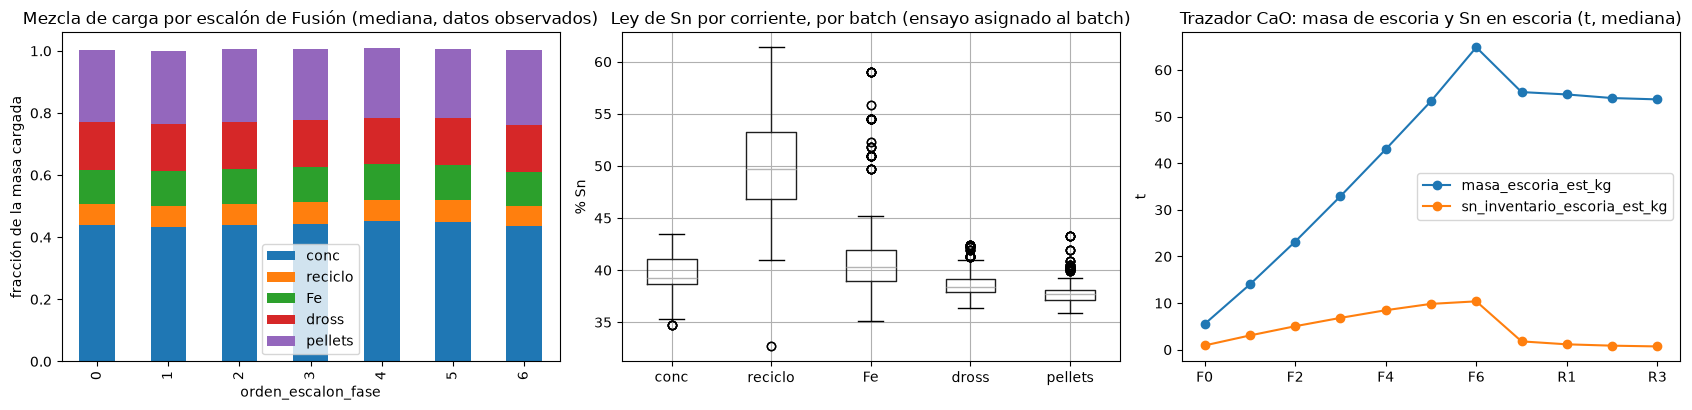

                                 masa_escoria_est_kg  sn_inventario_escoria_est_kg  avance_reduccion_sn_prev  relacion_CaO_carga  relacion_C_Sn_carga
fase_proceso orden_escalon_fase                                                                                                                      
Fusión       0                              5502.071                       910.815                       NaN               0.099                0.084
             1                             13999.877                      3053.679                     0.795               0.099                0.205
             2                             23173.118                      5032.421                     0.689               0.099                0.288
             3                             32909.511                      6820.704                     0.685               0.100                0.312
             4                             42975.579                      8462.098                  

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
mezcla = df.loc[F].groupby("orden_escalon_fase")[[f"frac_{c}_carga" for c in fe.TOLVAS_CARGA]].median()
mezcla.columns = list(fe.TOLVAS_CARGA); mezcla.plot.bar(stacked=True, ax=axes[0]); axes[0].set_title("Mezcla de carga por escalón de Fusión (mediana, datos observados)"); axes[0].set_ylabel("fracción de la masa cargada")
leyes = df.groupby("Batch")[[f"ley_sn_{c}_batch_pct" for c in fe.TOLVAS_CARGA]].first(); leyes.columns = list(fe.TOLVAS_CARGA)
leyes.replace(0, np.nan).boxplot(ax=axes[1]); axes[1].set_title("Ley de Sn por corriente, por batch (ensayo asignado al batch)"); axes[1].set_ylabel("% Sn")
inv = df.groupby(["fase_proceso", "orden_escalon_fase"])[["masa_escoria_est_kg", "sn_inventario_escoria_est_kg"]].median() / 1000
inv.index = [f"{'F' if f=='Fusión' else 'R'}{o}" for f, o in inv.index]
inv.plot(ax=axes[2], marker="o"); axes[2].set_title("Trazador CaO: masa de escoria y Sn en escoria (t, mediana)"); axes[2].set_ylabel("t")
plt.tight_layout(); plt.show()
print(df.groupby(["fase_proceso", "orden_escalon_fase"])[["masa_escoria_est_kg", "sn_inventario_escoria_est_kg", "avance_reduccion_sn_prev", "relacion_CaO_carga", "relacion_C_Sn_carga"]].median().round(3))

## Paso 58: targets de SALIDA en masa

`sn_extraido_est_kg = Sn cargado − Δ(Sn en escoria)`: kg de Sn que dejaron la fase escoria en el escalón (a metal crudo,
o a polvo). `frac_sn_extraido_escalon` lo normaliza por el Sn disponible (inventario previo + cargado) y vale en ambas
fases (a diferencia de T3, que en Fusión se inflaba por el Sn entrante). `feo_extraido_est_kg` es la señal de
sobre-reducción **en masa**.

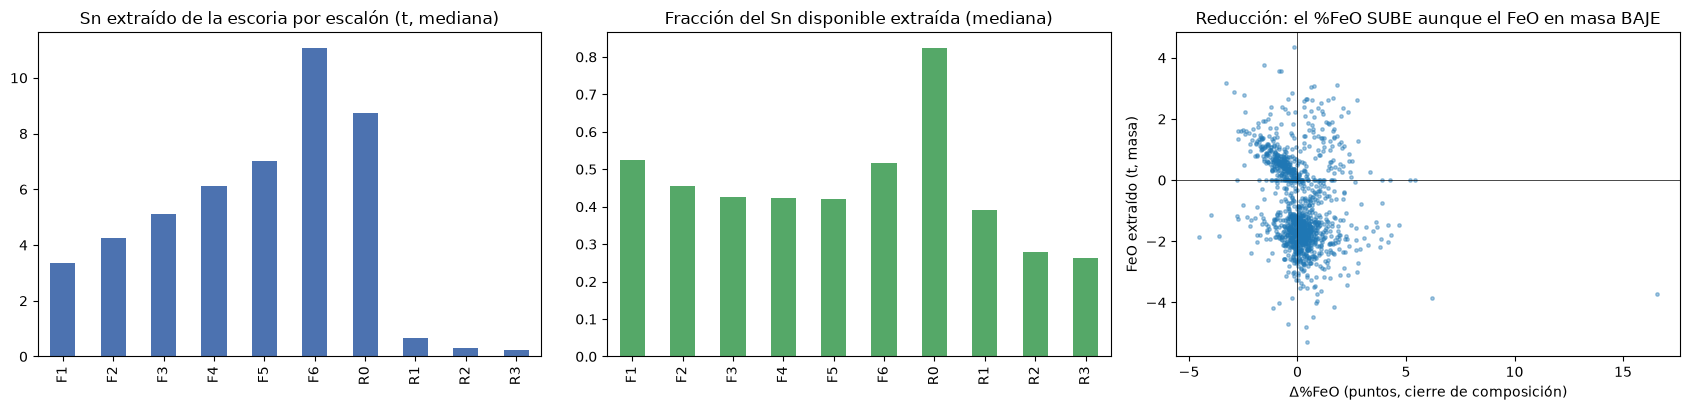

Reducción: Spearman Δ%FeO(pts) vs FeO extraído (kg): -0.322 | fracción de escalones con Δ%FeO>0: 0.5 | con FeO extraído>0: 0.3


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
t = df_base.groupby(["fase_proceso", "orden_escalon_fase"])[["sn_extraido_est_kg", "frac_sn_extraido_escalon", "feo_extraido_est_kg"]].median()
t.index = [f"{'F' if f=='Fusión' else 'R'}{o}" for f, o in t.index]
(t["sn_extraido_est_kg"] / 1000).plot.bar(ax=axes[0], color="#4C72B0"); axes[0].set_title("Sn extraído de la escoria por escalón (t, mediana)")
t["frac_sn_extraido_escalon"].plot.bar(ax=axes[1], color="#55A868"); axes[1].set_title("Fracción del Sn disponible extraída (mediana)")
d = df_base.loc[R]; axes[2].scatter(d["d_ley_feo_escoria_pct"], d["feo_extraido_est_kg"] / 1000, s=6, alpha=0.4)
axes[2].axhline(0, color="k", lw=0.5); axes[2].axvline(0, color="k", lw=0.5)
axes[2].set_xlabel("Δ%FeO (puntos, cierre de composición)"); axes[2].set_ylabel("FeO extraído (t, masa)"); axes[2].set_title("Reducción: el %FeO SUBE aunque el FeO en masa BAJE")
plt.tight_layout(); plt.show()
print("Reducción: Spearman Δ%FeO(pts) vs FeO extraído (kg):", round(spearmanr(d["d_ley_feo_escoria_pct"], d["feo_extraido_est_kg"], nan_policy="omit")[0], 3),
      "| fracción de escalones con Δ%FeO>0:", round((d["d_ley_feo_escoria_pct"] > 0).mean(), 2), "| con FeO extraído>0:", round((d["feo_extraido_est_kg"] > 0).mean(), 2))

## Paso 59: ¿qué target y qué features predicen mejor el efecto de las acciones? (experimentos/06 y 11)

Tres lecturas honestas: (1) en Fusión el target en masa da R² lockbox ≈0.70 frente a ≈0.45 del Δ%Sn, **pero** el
baseline trivial "solo Sn cargado" ya da ≈0.71 — la química agrega ~0.03 de R² OOF; (2) en Reducción el inventario
previo solo ya da 0.97-0.98 (el Sn se extrae casi por completo en R0); (3) el valor de las features v3 está en la
**respuesta a las palancas** (Paso 62), en la escala física común (kg) y en la restricción térmica, no en el R².

In [5]:
res06 = pd.read_csv(EXP / "06_resultados_targets_features.csv")
print("R2 lockbox (escala propia) — targets x feature sets x algoritmo")
display(res06.pivot_table(index=["fase", "target"], columns=["feature_set", "algoritmo"], values="r2_lockbox").round(3))
res11 = pd.read_csv(EXP / "11_sets_curados_resultados.csv")
print("\nSets curados vs baselines triviales (OOF = criterio de selección; lockbox = solo reporte)")
display(res11[["fase", "target", "set", "n_features", "r2_oof", "r2_lockbox", "mae_lockbox"]].round(3))

R2 lockbox (escala propia) — targets x feature sets x algoritmo


feature_set                                v2_actual               v3_carga         v3_carga+inventario         v3_pool_seguro        
algoritmo                             HistGB+mono(C) XGBoost HistGB+mono(C) XGBoost      HistGB+mono(C) XGBoost HistGB+mono(C) XGBoost
fase      target                                                                                                                      
Fusión    F1 d_ley_feo (pts %FeO)              0.102   0.101          0.039   0.104               0.111   0.141          0.083   0.123
          M1 sn_extraido_est_kg                0.697   0.703          0.622   0.667               0.656   0.711          0.716   0.714
          M2 frac_sn_extraido_escalon          0.019   0.037         -0.073   0.022              -0.030   0.032          0.003   0.055
          T1 d_ley_sn (pts %Sn)                0.441   0.468          0.354   0.312               0.327   0.352          0.282   0.328
          T3 tasa_relativa_sn                  0.656   0.666          0.565   0.580               0.515   0.581          0.552   0.575
Reducción F1 d_ley_feo (pts %FeO)              0.528   0.541          0.523   0.574               0.533   0.563          0.443   0.439
          F2 feo_extraido_est_kg               0.153   0.090          0.288   0.297               0.205   0.321          0.249   0.303
          M1 sn_extraido_est_kg                0.969   0.967          0.976   0.977               0.985   0.986          0.985   0.987
          M2 frac_sn_extraido_escalon          0.682   0.694          0.701   0.722               0.701   0.702          0.701   0.701
          T1 d_ley_sn (pts %Sn)                0.977   0.970          0.972   0.971               0.974   0.975          0.979   0.980
          T3 tasa_relativa_sn                  0.652   0.656          0.684   0.691               0.677   0.670          0.675   0.678


Sets curados vs baselines triviales (OOF = criterio de selección; lockbox = solo reporte)


,fase,target,set,n_features,r2_oof,r2_lockbox,mae_lockbox
0,Fusión,sn_extraido_est_kg,trivial_solo_Sn_cargado,1,0.685,0.714,1118.241
1,Fusión,sn_extraido_est_kg,trivial_Sn_cargado+inventario,3,0.716,0.714,1050.692
2,Fusión,sn_extraido_est_kg,curado_A_10,10,0.718,0.652,1169.056
3,Fusión,sn_extraido_est_kg,curado_B_13,13,0.722,0.680,1113.094
4,Fusión,sn_extraido_est_kg,curado_C_15,15,0.715,0.670,1162.145
5,Fusión,sn_extraido_est_kg,auto09_k8,8,0.740,0.701,1097.033
6,Fusión,d_ley_sn_escoria_pct,v2_actual_7,7,0.512,0.438,2.171
7,Fusión,d_ley_sn_escoria_pct,v2+masa_9,9,0.512,0.445,2.137
8,Fusión,d_ley_sn_escoria_pct,v2_plan_7,7,0.517,0.450,2.143
9,Fusión,d_ley_feo_escoria_pct,v2_actual_7,7,0.125,0.070,0.760


## Paso 60: deriva de campaña — por qué más features NO mejoran el lockbox en Fusión (experimentos/12)

Los últimos 63 batches (agosto 2026, lockbox) operan al **final de la campaña de refractario**: espesor 218-228 mm
(mínimo de DEV 235), termocuplas de carcasa 378-410 °C (P95 de DEV 384), ley de concentrado 41.5% (P95 de DEV 41.4),
baño más frío (995 vs 1077 °C). Dentro de DEV el walk-forward no cae (≈0.53 para todos los sets), pero cualquier feature
que codifique la campaña extrapola mal en el lockbox. Implicación operativa: **reentrenar/recalibrar a medida que
avanza la campaña**, y preferir sets sin contexto de campaña para el modelo de ley de Fusión.

In [6]:
log12 = (EXP / "12_diag_deriva_fusion_log.txt").read_text(encoding="utf-8")
filas = [dict(set=m.group(1).strip(), k=int(m.group(2)), r2_oof=float(m.group(3)), walk_forward=float(m.group(4)), lockbox=float(m.group(5)))
         for m in re.finditer(r"^(.+?)\s+k=\s*(\d+) R2 oof=([-\d.]+)\s+walk-forward=([-\d.]+)\s+lockbox=([-\d.]+)", log12, re.M)]
display(pd.DataFrame(filas))
ctx = ["espesor_ladrillo_norm_mm", "termocupla_media_celsius_prev", "ley_sn_conc_batch_pct", "temperatura_horno_celsius_prev"]
q = lambda s: s.quantile([.05, .5, .95]).round(1).tolist()
print(pd.DataFrame({c: {"dev P5/P50/P95": q(df_base.loc[F & df_base.Batch.isin(batches_dev), c]), "lockbox P5/P50/P95": q(df_base.loc[F & df_base.Batch.isin(batches_lockbox), c])} for c in ctx}).T)

,set,k,r2_oof,walk_forward,lockbox
0,v2,7,0.512,0.527,0.438
1,v2+carga,19,0.549,0.538,0.275
2,v2+lanza,13,0.528,0.514,0.394
3,v2+estado,12,0.511,0.519,0.391
4,v2+inventario,15,0.518,0.529,0.406
5,v2+contexto_tendencial,17,0.526,0.516,0.319
6,v2+carga+lanza+estado+inventario (sin contexto),38,0.542,0.540,0.349
7,todo,48,0.549,0.540,0.358


                                         dev P5/P50/P95      lockbox P5/P50/P95
espesor_ladrillo_norm_mm          [234.8, 270.9, 300.0]   [218.1, 221.6, 227.6]
termocupla_media_celsius_prev     [288.3, 327.0, 379.5]   [366.0, 388.4, 408.3]
ley_sn_conc_batch_pct                [36.5, 39.0, 41.4]      [37.5, 41.5, 43.5]
temperatura_horno_celsius_prev  [954.3, 1074.8, 1202.7]  [949.1, 990.6, 1037.7]


## Paso 61: configuración final v3 y validación (OOF dev / lockbox) por fase y target

`modelo_predictivo_v3.FEATURES_V3_POR_DEFECTO` (sets curados, interpretables, con signos SHAP verificados en
experimentos/11) y `TARGETS_V3`: `sn_kg` (objetivo), `sn_pts` (continuidad v1/v2), `feo_kg` (sobre-reducción en
masa, solo Reducción), `feo_pts` (informativo) y `dT` (restricción térmica).

In [7]:
tabla = mp3.tabla_validacion_v3(df) if RECALCULAR else pd.read_csv(EXP / "10_tabla_validacion_v3.csv").set_index(["fase", "target"])
display(tabla.round(3))
cob = pd.read_csv(EXP / "10_cobertura_cvplus_v3.csv"); print("Cobertura CV+ en lockbox (nominal 80%/90%):"); display(cob.round(3))
for fase in mp3.FASES:
    for k, v in mp3.FEATURES_V3_POR_DEFECTO[fase].items():
        print(f"{fase:9s} {k:7s} ({len(v):2d}): {v}")

columna  n_features  n_dev  n_lockbox  r2_oof   mae_oof  r2_lockbox  mae_lockbox  std_target_lockbox  r2_lockbox_equiv_dSn_pts
fase      target                                                                                                                                                     
Fusión    sn_kg             sn_extraido_est_kg          13   1749        374   0.722  1036.797       0.680     1113.094            2941.413                       NaN
          sn_pts          d_ley_sn_escoria_pct           7   1779        375   0.517     1.953       0.450        2.143               3.691                       NaN
          feo_pts        d_ley_feo_escoria_pct           9   1774        375   0.202     0.614       0.042        0.780               1.180                       NaN
          dT       d_temperatura_horno_celsius          15   1794        378   0.385    10.137       0.097        7.481               9.848                       NaN
Reducción sn_kg             sn_extraido_est_kg          10   1076        238   0.971   361.826       0.983      347.407            4386.336                     0.975
          sn_pts          d_ley_sn_escoria_pct          11   1093        242   0.948     0.658       0.968        0.655               6.115                       NaN
          feo_kg           feo_extraido_est_kg          11   1071        242   0.286   571.167       0.271      514.856             813.970                       NaN
          feo_pts        d_ley_feo_escoria_pct          11   1087        242   0.465     0.635       0.570        0.582               1.179                       NaN
          dT       d_temperatura_horno_celsius          14   1196        252   0.444     9.291       0.320        7.171              11.299                       NaN

Cobertura CV+ en lockbox (nominal 80%/90%):


,fase,target,nominal,cobertura_empirica,ancho_medio,n
0,Fusión,sn_kg,0.8,0.893,5063.386,374
1,Fusión,sn_kg,0.9,0.971,7061.033,374
2,Fusión,sn_pts,0.8,0.875,8.426,375
3,Fusión,sn_pts,0.9,0.941,10.915,375
4,Fusión,feo_pts,0.8,0.851,2.943,375
5,Fusión,feo_pts,0.9,0.931,4.329,375
6,Fusión,dT,0.8,0.981,47.488,378
7,Fusión,dT,0.9,1.000,59.784,378
8,Reducción,sn_kg,0.8,0.933,1693.271,238
9,Reducción,sn_kg,0.9,0.962,2597.099,238


Fusión    sn_kg   (13): ['feed_Sn_kgf', 'sn_inventario_escoria_est_kg_prev', 'masa_escoria_est_kg_prev', 'feo_inventario_escoria_est_kg_prev', 'ley_sn_escoria_pct_prev', 'interaccion_C_x_Sn_prev', 'tasa_feed_Carbon_kg_min', 'relacion_CaO_carga', 'tasa_gn_nm3_min', 'exceso_o2_combustion_pct', 'basicidad_B2_prev', 'temperatura_horno_celsius_prev', 'frac_carga_secundaria']
Fusión    sn_pts  ( 7): ['basicidad_B2_prev', 'duracion_plan_min', 'ley_sn_escoria_pct_prev', 'interaccion_C_x_Sn_prev', 'cum_feed_CaO_kg_prev', 'interaccion_Sn_x_FeO_prev', 'tasa_feed_Carbon_kg_min']
Fusión    feo_pts ( 9): ['ley_feo_escoria_pct_prev', 'ley_sio2_escoria_pct_prev', 'ley_sn_escoria_pct_prev', 'tasa_feed_CaO_kg_min', 'tasa_feed_Carbon_kg_min', 'exceso_o2_combustion_pct', 'tasa_feed_Fe_kg_min', 'tasa_feed_dross_Fe_kg_min', 'duracion_plan_min']
Fusión    dT      (15): ['temperatura_horno_celsius_prev', 'termocupla_media_celsius_prev', 'espesor_ladrillo_norm_mm', 'tasa_gn_nm3_min', 'tasa_o2_nm3_min', 'tasa_a

## Paso 62: efecto causal de las palancas dado el estado (DML cross-fitted, experimentos/07 y 10)

Efectos por 1 desviación estándar de cada palanca, controlando el estado v3 (inventario, leyes previas, temperatura,
refractario, ensayos del batch). Con el target **en masa**, en Fusión aparecen efectos ROBUSTOS que el target de ley no
identificaba: carbón (+), gas natural (+), tasa de carga (+), pellets y dross (+), cal/carga (−) y posición de lanza (−).

,fase,target,accion,n,theta_por_unidad,ci95_lo,ci95_hi,efecto_por_1sd_accion,efecto_por_1sd_en_sd_target,veredicto
0,Fusión,sn_extraido_est_kg,tasa_feed_Carbon_kg_min,1752,22.9061,1.8592,38.1981,195.9901,0.0645,ROBUSTO
1,Fusión,sn_extraido_est_kg,relacion_CaO_carga,1752,-18074.6911,-28381.9631,-4989.5081,-422.5619,-0.1390,ROBUSTO
2,Fusión,sn_extraido_est_kg,tasa_feed_total_kg_min,1752,8.5620,6.6028,11.1050,338.1325,0.1112,ROBUSTO
3,Fusión,sn_extraido_est_kg,frac_carga_secundaria,1746,2188.0421,-13.8898,4666.4022,200.9769,0.0661,NO_SIGNIFICATIVO
4,Fusión,sn_extraido_est_kg,tasa_feed_dross_Fe_kg_min,1746,14.5941,5.7976,22.3466,242.3202,0.0796,ROBUSTO
5,Fusión,sn_extraido_est_kg,tasa_feed_pellets_kg_min,1752,19.5242,11.6496,26.3014,467.5032,0.1538,ROBUSTO
6,Fusión,sn_extraido_est_kg,duracion_plan_min,1752,45.7358,-41.5246,144.0918,452.7808,0.1489,NO_SIGNIFICATIVO
7,Fusión,sn_extraido_est_kg,tasa_gn_nm3_min,1752,213.7125,153.3710,304.4989,315.3332,0.1037,ROBUSTO
8,Fusión,sn_extraido_est_kg,exceso_o2_combustion_pct,1752,2.2819,-24.5074,27.7471,6.2055,0.0020,NO_SIGNIFICATIVO
9,Fusión,sn_extraido_est_kg,posicion_vertical_lanza_mm,1752,-0.3382,-0.6504,-0.0735,-415.2716,-0.1366,ROBUSTO


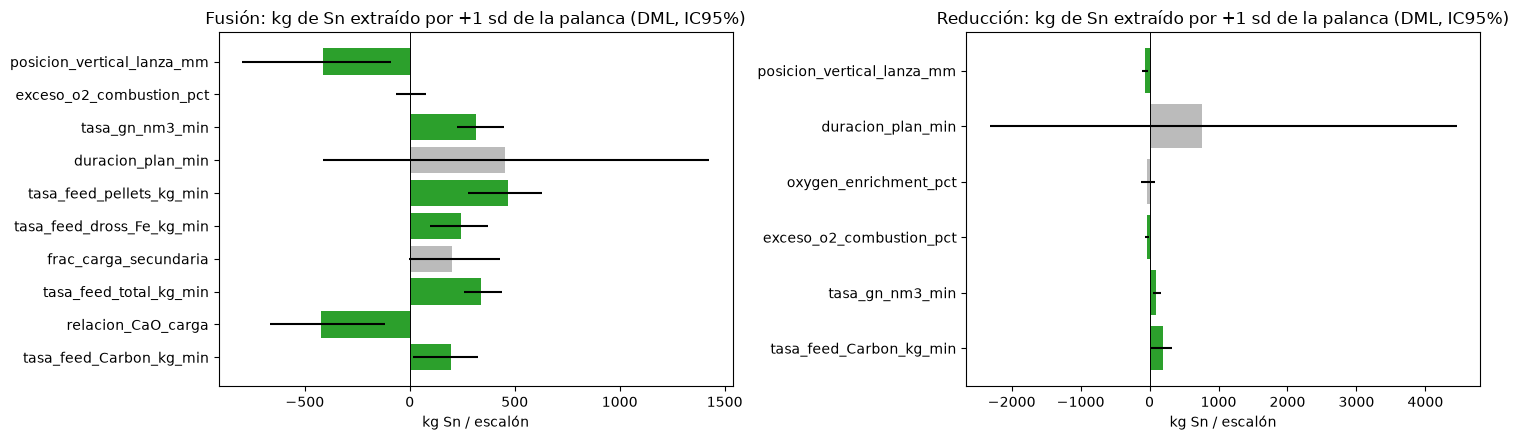

DML CONJUNTO (todas las palancas a la vez):


,palanca,theta_por_unidad,ci95_lo,ci95_hi,sd_palanca,efecto_por_1sd,efecto_1sd_ci95_lo,efecto_1sd_ci95_hi,significativo_ci95,n,target,fase,clave
0,tasa_feed_Carbon_kg_min,-2.542,-22.975,15.740,8.554,-21.745,-196.538,134.648,False,1749,sn_extraido_est_kg,Fusión,sn_kg
1,tasa_feed_CaO_kg_min,-42.638,-73.360,-11.492,9.451,-402.982,-693.351,-108.615,True,1749,sn_extraido_est_kg,Fusión,sn_kg
2,tasa_feed_total_kg_min,9.245,5.741,13.396,39.512,365.266,226.839,529.311,True,1749,sn_extraido_est_kg,Fusión,sn_kg
3,tasa_gn_nm3_min,89.336,0.454,198.764,1.476,131.864,0.671,293.384,True,1749,sn_extraido_est_kg,Fusión,sn_kg
4,tasa_o2_nm3_min,37.414,-9.612,88.318,3.347,125.216,-32.169,295.582,False,1749,sn_extraido_est_kg,Fusión,sn_kg
5,tasa_aire_nm3_min,3.973,-15.220,31.444,5.490,21.812,-83.567,172.643,False,1749,sn_extraido_est_kg,Fusión,sn_kg
6,duracion_plan_min,-3.305,-113.248,103.209,9.884,-32.662,-1119.346,1020.119,False,1749,sn_extraido_est_kg,Fusión,sn_kg
7,tasa_feed_Carbon_kg_min,-0.018,-0.049,0.010,8.659,-0.157,-0.423,0.088,False,1778,d_ley_sn_escoria_pct,Fusión,sn_pts
8,tasa_feed_CaO_kg_min,0.035,-0.014,0.090,9.466,0.333,-0.131,0.849,False,1778,d_ley_sn_escoria_pct,Fusión,sn_pts
9,tasa_feed_total_kg_min,0.017,0.012,0.023,41.124,0.704,0.512,0.949,True,1778,d_ley_sn_escoria_pct,Fusión,sn_pts


In [8]:
ef = pd.read_csv(EXP / "07_efectos_causales_v3.csv")
display(ef[["fase", "target", "accion", "n", "theta_por_unidad", "ci95_lo", "ci95_hi", "efecto_por_1sd_accion", "efecto_por_1sd_en_sd_target", "veredicto"]].round(4))
sub = ef[ef.target == "sn_extraido_est_kg"]
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for ax, fase in zip(axes, mp3.FASES):
    s = sub[sub.fase == fase].set_index("accion")
    err = np.vstack([s["efecto_por_1sd_accion"] - s["ci95_lo"] * s["efecto_por_1sd_accion"] / s["theta_por_unidad"].replace(0, np.nan),
                     s["ci95_hi"] * s["efecto_por_1sd_accion"] / s["theta_por_unidad"].replace(0, np.nan) - s["efecto_por_1sd_accion"]]).clip(0)
    colores = ["#2ca02c" if v == "ROBUSTO" else ("#ff7f0e" if v == "SIGNIFICATIVO_MODERADO" else "#bbbbbb") for v in s["veredicto"]]
    ax.barh(s.index, s["efecto_por_1sd_accion"], xerr=err, color=colores); ax.axvline(0, color="k", lw=0.7)
    ax.set_title(f"{fase}: kg de Sn extraído por +1 sd de la palanca (DML, IC95%)"); ax.set_xlabel("kg Sn / escalón")
plt.tight_layout(); plt.show()
conj = pd.read_csv(EXP / "10_efectos_palancas_conjunto_v3.csv"); print("DML CONJUNTO (todas las palancas a la vez):"); display(conj.round(3))

## Paso 63: el precio físico de sobre-reducir — λ_Fe (kg Sn a dross por kg FeO reducido)

A nivel batch, el FeO extraído de la escoria en Reducción (masa, trazador CaO) se asocia al Sn que termina en dross de
Fe: OLS `Sn_dross (t) ~ FeO_extraído (t)` da pendiente ≈0.3 (IC95% 0.08-0.49, p=0.007). Es el peso `lambda_fe` del
objetivo v3, en las mismas unidades que el Sn extraído. La regresión explica poco (R² 0.03: el KPI de batch es
ruidoso) pero fija el orden de magnitud con sentido físico.

                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            5.8274      0.269     21.678      0.000       5.299       6.356
feo_extr_R_t     0.2903      0.108      2.684      0.008       0.078       0.503


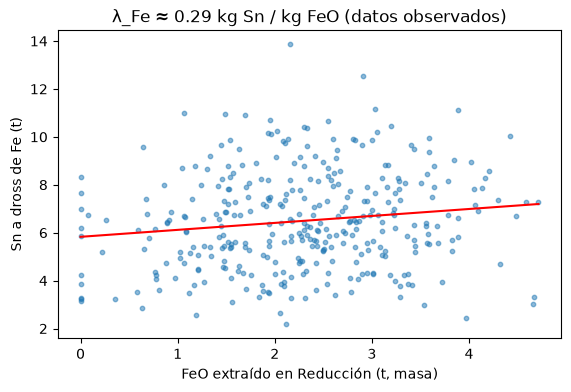

Spearman selectividad en masa (Sn/FeO extraídos) vs rendimiento HA: 0.2


In [9]:
import statsmodels.api as sm
b = pd.DataFrame({"dross_t": df.groupby("Batch")["sn_en_dross_fe_batch_t"].first(),
                  "feo_extr_R_t": df.loc[R].groupby("Batch")["feo_extraido_est_kg"].sum() / 1000,
                  "sel_masa": df.loc[R].groupby("Batch")["sn_extraido_est_kg"].sum() / df.loc[R].groupby("Batch")["feo_extraido_est_kg"].sum(),
                  "rha": df.groupby("Batch")["rendimiento_ha_batch"].first()}).dropna()
b = b[b.feo_extr_R_t.between(*b.feo_extr_R_t.quantile([.02, .98]))]
m = sm.OLS(b.dross_t, sm.add_constant(b[["feo_extr_R_t"]])).fit(); print(m.summary().tables[1])
fig, ax = plt.subplots(figsize=(6.5, 4)); ax.scatter(b.feo_extr_R_t, b.dross_t, s=10, alpha=0.5)
xs = np.linspace(b.feo_extr_R_t.min(), b.feo_extr_R_t.max(), 10); ax.plot(xs, m.params.iloc[0] + m.params.iloc[1] * xs, "r-")
ax.set_xlabel("FeO extraído en Reducción (t, masa)"); ax.set_ylabel("Sn a dross de Fe (t)"); ax.set_title(f"λ_Fe ≈ {m.params.iloc[1]:.2f} kg Sn / kg FeO (datos observados)"); plt.show()
print("Spearman selectividad en masa (Sn/FeO extraídos) vs rendimiento HA:", round(spearmanr(b.sel_masa, b.rha, nan_policy='omit')[0], 3))

## Paso 63b: ¿conviene extraer Sn durante la Fusión? La evidencia de batch dice que NO (λ_F)

El Sn extraído de la escoria a lo largo del batch es ≈ fijo (Sn cargado − ≈1 t en la escoria final): extraer más en Fusión
solo deja menos para Reducción. Lo que sí varía entre batches es **cuándo** se extrae. La fracción del Sn cargado que ya
salió de la escoria al fin de Fusión (`F_avance_final`) **reduce** la fracción a metal (OLS −0.143, t=−3.7, controlando
ley del concentrado, refractario, temperatura y FeO reducido) y **aumenta** el dross (+0.085, p=0.004); cada t de Sn
conservada en la escoria al fin de Fusión suma ≈0.13 t de metal (p=0.001). Es el principio de dos etapas del horno de Sn:
fundir oxidando manteniendo el Sn como SnO₂ en la escoria, y reducirlo después con selectividad controlada. Por eso el
objetivo de Fusión en v3 penaliza la extracción prematura (`w_sn = −λ_F = −0.13`).

In [10]:
gF, gR = df.loc[F].groupby("Batch"), df.loc[R].groupby("Batch"); g = df.groupby("Batch")
bb = pd.DataFrame({"feedsn_t": g["feed_Sn_kgf"].sum() / 1000, "metal": g["sn_en_metal_crudo_batch_t"].first(), "dross": g["sn_en_dross_fe_batch_t"].first(),
                   "F_avance_final": 1 - gF["sn_inventario_escoria_est_kg"].last() / gF["feed_Sn_kgf"].sum(), "F_sn_esc_final_t": gF["sn_inventario_escoria_est_kg"].last() / 1000,
                   "ley_conc": g["ley_sn_conc_batch_pct"].first(), "esp": g["espesor_ladrillo_norm_mm"].first(), "F_T_mean": gF["temperatura_horno_celsius"].mean(),
                   "R_feo_extr_t": gR["feo_extraido_est_kg"].sum() / 1000}).dropna()
bb["f_metal"] = bb.metal / bb.feedsn_t; bb["f_dross"] = bb.dross / bb.feedsn_t
print(sm.OLS(bb.f_metal, sm.add_constant(bb[["F_avance_final", "ley_conc", "esp", "F_T_mean", "R_feo_extr_t"]])).fit().summary().tables[1])
print(sm.OLS(bb.f_dross, sm.add_constant(bb[["F_avance_final", "R_feo_extr_t", "ley_conc"]])).fit().summary().tables[1])
print(sm.OLS(bb.metal, sm.add_constant(bb[["F_sn_esc_final_t", "feedsn_t"]])).fit().summary().tables[1])
bb["q"] = pd.qcut(bb.F_avance_final, 5, labels=False)
display(bb.groupby("q")[["F_avance_final", "f_metal", "f_dross", "R_feo_extr_t"]].mean().round(3).rename_axis("quintil de avance al fin de Fusión"))

                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.9582      0.082     11.616      0.000       0.796       1.120
F_avance_final    -0.1433      0.039     -3.689      0.000      -0.220      -0.067
ley_conc          -0.0013      0.002     -0.837      0.403      -0.004       0.002
esp            -9.016e-05      0.000     -0.509      0.611      -0.000       0.000
F_T_mean       -5.349e-05   6.23e-05     -0.859      0.391      -0.000     6.9e-05
R_feo_extr_t      -0.0070      0.002     -2.859      0.005      -0.012      -0.002
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.0405      0.052     -0.785      0.433      -0.142       0.061
F_avance_final     0.0845      0.029      2.928      0.004       0.028       0.141
R_fe

,F_avance_final,f_metal,f_dross,R_feo_extr_t
quintil de avance al fin de Fusión,,,,
0,0.704,0.705,0.116,2.515
1,0.762,0.717,0.124,2.330
2,0.794,0.690,0.129,2.449
3,0.827,0.682,0.132,2.301
4,0.898,0.681,0.132,1.836


## Paso 64: prescriptor v3 — recomendaciones por escalón en kg de metal equivalente

`J_R = Sn extraído [kg] − λ_Fe·FeO reducido [kg] − costos (C, GN, O₂, tiempo) − w_T·(T fuera de P5-P95) − w_U·ancho CV+ − w_S·(1 − soporte)`
y `J_F = −λ_F·Sn extraído [kg] − costos − …` (Paso 63b). En Reducción el optimizador mueve carbón, GN, O₂, aire y duración
planificada; en Fusión solo carbón y cal (los gases, la carga y la duración quedan en el plan del operador porque el
modelo térmico de Fusión es débil). Restricción dura de soporte histórico (≥ P10) y penalización blanda. Cada escalón
parte de su estado real (sin encadenar); el resumen del batch está en **kg de metal equivalente** (−λ_F·ΔSn_Fusión +
ΔSn_Reducción − λ_Fe·ΔFeO_Reducción), nunca como suma de "Sn extraído".

In [11]:
sistema = mp3.entrenar_sistema_v3(df)
pol = pd.read_csv(EXP / "10_politica_lockbox_v3.csv").set_index("Batch"); print("Política recomendada vs histórica en 8 batches del lockbox (kg Sn, estimado por el modelo):"); display(pol.round(1))
batch = pol.index[0]
rep = mp3.reporte_recomendaciones_batch_v3(sistema, df, batch, n_candidatos=150)
cols = ["fase", "orden_escalon_fase", "ley_sn_escoria_pct_prev", "sn_extraido_real_kg", "pred_sn_kg_historico", "pred_sn_kg_recomendado",
        "pred_feo_reducido_kg_historico", "pred_feo_reducido_kg_recomendado", "pred_T_recomendado", "support_recomendado", "uplift_J_kgSn",
        "hist__tasa_feed_Carbon_kg_min", "rec__tasa_feed_Carbon_kg_min", "hist__tasa_gn_nm3_min", "rec__tasa_gn_nm3_min",
        "hist__tasa_o2_nm3_min", "rec__tasa_o2_nm3_min", "hist__duracion_plan_min", "rec__duracion_plan_min"]
display(rep[[c for c in cols if c in rep.columns]].round(1)); print(mp3.resumen_reporte_batch_v3(rep))

Política recomendada vs histórica en 8 batches del lockbox (kg Sn, estimado por el modelo):


,n_escalones_evaluados,fusion_sn_extraido_adicional_kg,reduccion_sn_extraido_adicional_kg,reduccion_feo_reducido_adicional_kg,metal_equivalente_kg,uplift_J_total_kgSn,pct_escalones_con_mejora,support_medio_historico,support_medio_recomendado,rendimiento_ha_batch
Batch,,,,,,,,,,
AP0300,10,-2238.0,733.2,-113.3,1058.1,3030.3,90.0,0.3,0.4,0.6
AP0301,10,-1737.5,1043.5,-354.0,1375.5,2637.1,100.0,0.4,0.4,0.6
AP0302,10,-1064.0,822.4,455.3,824.2,1717.7,90.0,0.3,0.4,0.7
AP0303,10,-1451.5,910.7,1323.8,702.2,2643.9,100.0,0.3,0.4,0.7
AP0304,10,-452.2,359.0,-92.3,445.5,2998.4,100.0,0.3,0.4,0.7
AP0305,10,-517.6,360.5,379.5,313.9,1268.5,80.0,0.4,0.4,0.8
AP0306,10,-1137.7,541.5,114.5,655.1,1665.8,100.0,0.4,0.4,0.7
AP0307,10,-1229.8,440.7,124.4,563.3,1327.8,100.0,0.4,0.5,0.7


,fase,orden_escalon_fase,ley_sn_escoria_pct_prev,sn_extraido_real_kg,pred_sn_kg_historico,pred_sn_kg_recomendado,pred_feo_reducido_kg_historico,pred_feo_reducido_kg_recomendado,pred_T_recomendado,support_recomendado,uplift_J_kgSn,hist__tasa_feed_Carbon_kg_min,rec__tasa_feed_Carbon_kg_min,hist__tasa_gn_nm3_min,rec__tasa_gn_nm3_min,hist__tasa_o2_nm3_min,rec__tasa_o2_nm3_min,hist__duracion_plan_min,rec__duracion_plan_min
0,Fusión,1,7.7,2985.2,3500.4,3479.0,0.0,3.7,1031.4,0.4,295.4,22.4,38.4,31.4,31.4,49.3,49.3,35.0,35.0
1,Fusión,2,24.1,4287.6,4979.8,4832.2,0.0,0.0,1021.3,0.5,60.8,38.2,40.4,31.4,31.4,49.7,49.7,40.0,40.0
2,Fusión,3,25.2,5670.8,5201.2,4970.4,0.0,0.0,1040.1,0.4,112.7,41.7,50.9,31.9,31.9,51.1,51.1,45.0,45.0
3,Fusión,4,23.7,7193.6,5969.4,5756.8,0.0,0.0,1023.8,0.4,158.6,44.6,50.3,31.4,31.4,50.5,50.5,50.0,50.0
4,Fusión,5,21.3,5804.4,9024.3,8408.5,0.0,0.0,1029.4,0.4,54.8,53.3,49.2,32.1,32.1,51.2,51.2,55.0,55.0
5,Fusión,6,22.6,7641.7,9670.1,8660.3,0.0,32.0,1034.4,0.4,522.1,56.3,49.4,32.1,32.1,51.2,51.2,47.0,47.0
6,Reducción,0,21.2,9416.6,12349.7,12897.8,1633.7,1326.8,1010.3,0.3,795.9,63.0,61.3,27.6,28.7,31.3,30.5,30.0,30.0
7,Reducción,1,10.3,5014.5,5292.7,5292.7,1175.1,1175.1,976.8,0.1,0.0,32.4,32.4,20.4,20.4,24.9,24.9,25.0,25.0
8,Reducción,2,2.7,304.8,303.5,395.6,0.0,0.0,960.7,0.4,683.5,10.8,33.2,13.2,24.5,16.4,25.2,20.0,27.1
9,Reducción,3,2.1,77.0,194.6,287.5,329.8,523.5,955.1,0.4,346.4,5.8,12.5,17.3,20.5,13.1,21.8,13.0,13.3


{'n_escalones_evaluados': 10, 'fusion_sn_extraido_adicional_kg': -2238.0030644948565, 'reduccion_sn_extraido_adicional_kg': 733.1648035212427, 'reduccion_feo_reducido_adicional_kg': -113.26104948803822, 'metal_equivalente_kg': 1058.0835167519854, 'uplift_J_total_kgSn': 3030.3055902978917, 'pct_escalones_con_mejora': 90.0, 'support_medio_historico': 0.28630187247817696, 'support_medio_recomendado': 0.3795057922449376}


In [12]:
row = df_base[(df_base.Batch == batch) & (df_base.fase_proceso == "Reducción")].sort_values("fecha_inicio").iloc[0]
state, action, context = mp3.fila_a_state_action_context("Reducción", row)
print(f"Sensibilidad local del modelo en {batch} R0 (efecto de cada palanca DADO este estado):")
display(mp3.sensibilidad_local_v3(sistema, "Reducción", state, action, context).round(3))
sim = mp3.simulate_action_v3(sistema, "Reducción", state, action, context)
print({k: (round(v, 1) if isinstance(v, float) else v) for k, v in sim.items() if k not in ("derivadas",)})

Sensibilidad local del modelo en AP0300 R0 (efecto de cada palanca DADO este estado):


,valor_actual,paso,d_sn_kg_por_unidad,d_feo_reducido_kg_por_unidad,d_T_por_unidad,d_sn_kg_en_el_paso,d_feo_reducido_kg_en_el_paso,d_T_en_el_paso
palanca,,,,,,,,
tasa_feed_Carbon_kg_min,62.965,9.536,11.860,47.696,-0.223,113.094,454.827,-2.128
tasa_gn_nm3_min,27.555,3.845,93.584,-32.942,0.439,359.827,-126.663,1.689
tasa_o2_nm3_min,31.289,2.675,-1.007,-23.752,-2.235,-2.693,-63.539,-5.980
tasa_aire_nm3_min,121.110,11.161,0.267,7.213,-0.568,2.981,80.502,-6.337
duracion_plan_min,30.000,1.700,0.000,0.000,0.000,0.000,0.000,0.000


{'fase': 'Reducción', 'pred_sn_extraido_kg': 12349.7, 'intervalo_sn_kg': (11456.21302011009, 13269.507640639664), 'pred_d_ley_sn_pts': -14.9, 'intervalo_d_ley_sn_pts': (-17.284956845656303, -11.924398407004325), 'pred_feo_reducido_kg': 1633.7, 'pred_feo_extraido_kg': 1633.7, 'intervalo_feo_kg': (371.01580344745435, 2957.42883796962), 'pred_d_ley_feo_pts': 2.3, 'pred_dT': -13.1, 'intervalo_dT': (-34.33321447600626, 8.04446827386624), 'pred_temperatura': 1004.7, 'support_score': 0.2}


## Paso 65: el rendimiento del batch y sus dos canales de pérdida (experimentos/08)

`rendimiento_ha_batch` se descompone en Sn a **dross de Fe** (12.7% ± 3.9 del Sn cargado; ρ=−0.76 con el rendimiento)
y Sn a **polvo** (18.3% ± 4.0; ρ=−0.54), independientes entre sí (ρ=0.02). El canal de dross responde a la
sobre-reducción de FeO en Reducción (caída de FeO, selectividad en masa); el de polvo no se explica con los agregados
disponibles. El KPI de batch sigue siendo poco predecible (R² lockbox ≈0, Spearman 0.25-0.40): el valor prescriptivo
está en el escalón, con el eslabón al batch dado por λ_Fe y el balance de Sn en masa.

In [13]:
cors = pd.read_csv(EXP / "08_spearman_batch.csv", index_col=0)
display(cors.loc[cors.abs().max(axis=1) > 0.2].round(3).sort_values("frac_sn_dross"))
display(pd.read_csv(EXP / "08_resultados_batch.csv")[["target", "modelo", "r2_oof", "r2_walkforward", "r2_lockbox", "rho_lockbox"]].round(3))

,rendimiento_ha_batch,frac_sn_dross,frac_sn_polvo,frac_sn_metal
reduccion_feo_caida_total,0.274,-0.251,-0.069,0.216
delta_FR_ley_feo_escoria_pct,0.238,-0.247,0.011,0.249
R_selectividad_masa,0.246,-0.234,-0.071,0.142
reduccion_carbon_total_kg,0.135,-0.233,0.122,0.156
F_C_por_t_Sn,0.095,-0.232,0.153,0.066
F_lanza_mean,0.116,-0.209,0.082,0.140
fusion_ley_sn_pico,0.077,-0.209,0.134,0.076
fusion_ley_sn_final,0.113,-0.146,0.101,0.216
reduccion_ley_sn_inicio,0.113,-0.146,0.101,0.216
F_sn_escoria_final_t,0.100,-0.130,0.089,0.201


,target,modelo,r2_oof,r2_walkforward,r2_lockbox,rho_lockbox
0,rendimiento_ha_batch,XGB_chico,1.140000e-01,-0.039,0.007,0.242
1,rendimiento_ha_batch,XGB_top8,1.330000e-01,NaN,-0.062,0.261
2,rendimiento_ha_batch,ElasticNet,-1.136686e+35,-0.028,-0.072,0.162
3,frac_sn_dross,XGB_chico,1.790000e-01,-0.034,0.025,0.397
4,frac_sn_dross,XGB_top8,1.830000e-01,NaN,-0.008,0.345
5,frac_sn_dross,ElasticNet,-2.939471e+36,-0.030,0.007,0.369
6,frac_sn_polvo,XGB_chico,3.500000e-02,-0.132,-0.282,-0.225
7,frac_sn_polvo,XGB_top8,1.070000e-01,NaN,-0.270,-0.022
8,frac_sn_polvo,ElasticNet,3.700000e-02,-0.068,-0.125,-0.042
9,frac_sn_metal,XGB_chico,1.710000e-01,0.079,-0.024,0.408


## Paso 66: conclusiones y limitaciones

1. **Datos**: `feed_CaO_kgh` corregido (tolva 6); el Sn por tolva es `tmh × ley del batch`; `duracion_plan_min` es la
   acción de tiempo limpia; sin heel entre batches; Rendimiento HA ≡ rendimiento_proxy_batch.
2. **Masa de escoria por trazador CaO** cierra el cuello de botella declarado desde hallazgos.md 6b: targets en kg,
   inventario de Sn/FeO, avance de reducción, y muestra que el Δ%FeO en puntos **no** mide sobre-reducción en Reducción
   (sube por cierre de composición cuando sale el Sn).
3. **Predicción**: Reducción sigue excelente (Δ%Sn lockbox ≈0.97; kg ≈0.98); Fusión mejora en kg (≈0.70) pero casi
   todo es la carga; el ΔT de Reducción pasa a ser predecible (≈0.3-0.5). Deriva de campaña en el lockbox → reentrenar.
4. **Efecto de las acciones dado el estado**: DML con el target en masa identifica palancas ROBUSTAS en Fusión (carbón +,
   GN +, cal/carga −, lanza −, carga/pellets/dross +) y confirma carbón/GN/O2 en Reducción.
5. **Dirección de Fusión**: extraer Sn prematuramente cuesta ≈0.13 kg de metal por kg (evidencia de batch, t=−3.7):
   el prescriptor de Fusión conserva el Sn en la escoria (menos carbón / más cal dentro del soporte histórico) y el de
   Reducción lo extrae con selectividad (λ_Fe ≈ 0.3 kg Sn/kg FeO). Objetivo en kg de metal equivalente, ventana
   térmica, intervalos CV+ conservadores, soporte histórico duro (P10) y blando; reporte por batch y sensibilidad local.
6. **Pendientes de planta**: sentido físico de la posición de lanza; por qué la tolva 4 (mineral de Fe) tiene ~40% Sn;
   CaO de la ganga (para calibrar la masa absoluta de escoria); precios reales para los costos del objetivo.